# Explaining Anomaly Detection using VAE-GAN models

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sys,importlib,os

In [6]:
import tensorflow.keras as keras
import tensorflow.keras.layers as layers

In [ ]:
class Model_VAE_GAN_functions():
    class Sampling(layers.Layer):
        """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon
    def get_encoder(latent_dim=None,image_size=[128, 128],print_summary=False):
        a,b        = image_size
        shape      = (a, b,3)
        encoder_inputs = keras.Input(shape=shape)
        x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.Flatten()(x)
        x = layers.Dense(160, activation="tanh")(x)
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
        z = Model_VAE_GAN_functions.Sampling()([z_mean, z_log_var])
        encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
        if print_summary:
            encoder.summary()
        return encoder
    def get_decoder(latent_dim=None,print_summary=False):
        latent_inputs = keras.Input(shape=(latent_dim,))
        x = layers.Dense(8* 8 * 64, activation="relu")(latent_inputs)
        x = layers.Reshape((8, 8, 64))(x)
        x = layers.Conv2DTranspose(256, 2, activation="relu", strides=2, padding="same")(x)
        x = layers.Conv2D(256, 3, activation="relu", strides=1, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2DTranspose(128, 2, activation="relu", strides=2, padding="same")(x)
        x = layers.Conv2D(128, 3, activation="relu", strides=1, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2DTranspose(64, 2, activation="relu", strides=2, padding="same")(x)
        x = layers.Conv2D(64, 3, activation="relu", strides=1, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2DTranspose(32, 2, activation="relu", strides=2, padding="same")(x)
        x = layers.Conv2D(32, 3, activation="relu", strides=1, padding="same")(x)
        decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
        decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
        if print_summary:
            decoder.summary()
        return decoder
    def get_discriminator(shape=None,print_summary=False):
        discriminator_inputs = keras.Input(shape=shape)
        x = layers.Conv2D(128, 8, activation="relu", strides=2, padding="same")(discriminator_inputs)
        x = layers.MaxPool2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, 5, activation="relu", strides=2, padding="same")(x)
        x = layers.MaxPool2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(32, 4, activation="relu", strides=2, padding="same")(x)
        x = layers.Flatten()(x)
        x = layers.Dense(128, activation="relu")(x)
        discriminator_outputs = layers.Dense(1,activation="sigmoid")(x)
        discriminator = keras.Model(discriminator_inputs, discriminator_outputs, name="discriminator")
        if print_summary:
            discriminator.summary()
        return discriminator
###########################################################################################
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        
    def call(self,x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        return z,reconstruction
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]
    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))            
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
###########################################################################################
class VAE_GAN(keras.Model):    
    def __init__(self, vae, discriminator, opti1=keras.optimizers.Adam(), opti2=keras.optimizers.Adam(), opti3=keras.optimizers.Adam(), **kwargs):
        super(VAE_GAN, self).__init__(**kwargs)
        self.encoder = vae.encoder
        self.decoder = vae.decoder
        self.discriminator = discriminator
        self.vae = vae
        self.vae_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.correlation_loss_tracker = keras.metrics.Mean(name="cr_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="disc_loss")
        self.gen_loss_tracker = keras.metrics.Mean(name="gen_loss")
        self.disc_loss = keras.losses.BinaryCrossentropy()
        self.vae_optimizer = opti1
        self.gen_optimizer = opti2
        self.disc_optimizer = opti3
    def call(self,x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        return z,reconstruction
    @property
    def metrics(self):
        return [
            self.vae_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
            self.correlation_loss_tracker,
            self.disc_loss_tracker,
            self.gen_loss_tracker
        ]
    def train_step(self, data):        
        batch_size = K.shape(data)[0]    
        with tf.GradientTape() as enc_tape, tf.GradientTape() as dec_tape, tf.GradientTape() as disc_tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            recon_vect = z#tf.random.normal((batch_size, latent_dim))
            contruction = self.decoder(recon_vect)
            combined_images = tf.concat([data, contruction], axis=0)
            data_l,recon_l = tf.zeros((batch_size, 1)),tf.ones((batch_size, 1))
            combined_l = tf.concat([data_l, recon_l], axis=0)
            tot_predictions = self.discriminator(combined_images)
            r_prediction = self.discriminator(contruction)
            discr_loss = self.disc_loss(combined_l,tot_predictions)
            gen_loss = tf.math.maximum(self.disc_loss(data_l,r_prediction) - discr_loss,.0001)
            vae_loss = reconstruction_loss + kl_loss + gen_loss #+.1*coorelation_loss 
        grad_discr = disc_tape.gradient(discr_loss, self.discriminator.trainable_weights)
        grad_vae = enc_tape.gradient(vae_loss, self.vae.trainable_weights)       
        self.disc_optimizer.apply_gradients(zip(grad_discr, self.discriminator.trainable_weights))
        self.vae_optimizer.apply_gradients(zip(grad_vae, self.vae.trainable_weights))

        self.vae_loss_tracker.update_state(vae_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.disc_loss_tracker.update_state(discr_loss)
        self.gen_loss_tracker.update_state(gen_loss)
        return {
            "vae_loss": self.vae_loss_tracker.result(),
            "disc_loss": self.disc_loss_tracker.result(),
            "gen_los": self.gen_loss_tracker.result(),
        }

In [17]:
import pandas as pd
def get_BlackBox_VAE_GAN(image_size=[128,128], latent_dim=32,print_summary=False):
    """
    Loads a pretrained VAE-GAN model + history.
    Returns:
        model, history_frame
    """
    # -------------------------------------------------------
    # builder
    # -------------------------------------------------------
    def build_model(image_size, latent_dim=latent_dim):
        encoder = Model_VAE_GAN_functions.get_encoder(latent_dim=latent_dim, print_summary=print_summary)
        decoder = Model_VAE_GAN_functions.get_decoder(latent_dim=latent_dim, print_summary=print_summary)
        discriminator = Model_VAE_GAN_functions.get_discriminator(shape=image_size + [3], print_summary=print_summary)
        vae = VAE(encoder, decoder)
        return VAE_GAN(vae, discriminator)
    # -------------------------------------------------------
    # Build + compile model
    # -------------------------------------------------------
    model = build_model(image_size, latent_dim)
    model.compile(optimizer=tf.keras.optimizers.Adam())
    print("Model built and compiled.")
    return model

In [18]:
model = get_BlackBox_VAE_GAN(image_size=[128,128], latent_dim=32,print_summary=False)

Model built and compiled.


## Load Pretrained-BlackBox model
- pretrained weights are provided at https://github.com/rashidrao-pk/anomaly_detection_trust_case_study/tree/main
- these pretrained weights only can be downloaded by visiting link https://download-directory.github.io/?url=https%3A%2F%2Fgithub.com%2Frashidrao-pk%2Fanomaly_detection_trust_case_study%2Ftree%2Fmain%2Fmodels%2Fhazelnut_VAE_GAN_30000


In [29]:
import os
import pandas as pd

def load_pretrained_weight(path_models, model, ds_name='hazelnut', num_epochs=30000):
    """
    Load pretrained VAE-GAN weights + history.
    If weights for hazelnut_VAE_GAN_30000 are not found locally,
    they are downloaded from GitHub and extracted automatically.
    """
    # -------------------------------------------------------
    # Helper: download weights from GitHub if missing
    # -------------------------------------------------------
    def maybe_download_weights(path_models, ds_name, num_epochs):
        model_dir = os.path.abspath(f"{path_models}/{ds_name}_VAE_GAN_{num_epochs}")
        prefix = os.path.join(model_dir, f"{ds_name}_VAE_GAN_{num_epochs}")
        history_file = prefix + ".csv"

        # If already present, nothing to do
        if os.path.exists(history_file):
            return model_dir, prefix, history_file

        # Only auto-download for the hazelnut 30000-epochs model
        if not (ds_name == 'hazelnut' and num_epochs == 30000):
            print(f"[WARN] No local history found at {history_file} "
                  f"and auto-download is only implemented for hazelnut_VAE_GAN_30000.")
            return model_dir, prefix, history_file

        print(f"[INFO] Weights not found at {history_file}.")
        print("[INFO] Downloading hazelnut_VAE_GAN_30000 weights from GitHub...")

        import io
        import zipfile
        import requests

        # Zip of the whole repo
        repo_zip_url = (
            "https://github.com/rashidrao-pk/"
            "anomaly_detection_trust_case_study/archive/refs/heads/main.zip"
        )
        resp = requests.get(repo_zip_url)
        resp.raise_for_status()

        # Open zip in-memory
        zf = zipfile.ZipFile(io.BytesIO(resp.content))

        # Folder inside the zip where the weights live
        # (GitHub archives repo under REPO-NAME-main/)
        subdir_in_zip = "anomaly_detection_trust_case_study-main/models/hazelnut_VAE_GAN_30000/"

        # Where to put them locally
        os.makedirs(model_dir, exist_ok=True)

        for member in zf.namelist():
            if not member.startswith(subdir_in_zip):
                continue
            rel_path = member[len(subdir_in_zip):]  # strip leading folder
            if not rel_path:  # skip the root folder entry
                continue

            target_path = os.path.join(model_dir, rel_path)
            if member.endswith("/"):  # directory
                os.makedirs(target_path, exist_ok=True)
            else:
                # ensure parent dir exists
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
                with zf.open(member) as src, open(target_path, "wb") as dst:
                    dst.write(src.read())
    
        print(f"[INFO] Downloaded and extracted weights to: {model_dir}")
        return model_dir, prefix, history_file

    # -------------------------------------------------------
    # Helper: actually load all component weights
    # -------------------------------------------------------
    def load_weights(model, prefix):
        model.load_weights(prefix + "_model")
        model.vae.load_weights(prefix + "_vae")
        model.vae.encoder.load_weights(prefix + "_encoder")
        model.vae.decoder.load_weights(prefix + "_decoder")
        model.discriminator.load_weights(prefix + "_discriminator")
        return model

    # -------------------------------------------------------
    # Main logic
    # -------------------------------------------------------
    model_dir, prefix, history_file = maybe_download_weights(
        path_models, ds_name, num_epochs
    )

    if os.path.exists(history_file):
        model = load_weights(model, prefix)
        history_frame = pd.read_csv(history_file)
        print(f"[OK] Loaded model from: {prefix}")
        print(f"[OK] Epochs trained: {len(history_frame)}")
    else:
        print(f"[WARN] Model NOT found even after download attempt: {history_file}")
        history_frame = None

    return model, history_frame


In [34]:
path_models = "./pretrained_models"
# path_models =   os.path.join(os.path.dirname(os.getcwd()), 'notebooks','E6_XAD','models')
model, history = load_pretrained_weight(path_models,model)

[OK] Loaded model from: e:\PHD\datacloud_data\repos\my_git\papers_repo\shap_bpt_tests\minimal_notebooks\pretrained_models\hazelnut_VAE_GAN_30000\hazelnut_VAE_GAN_30000
[OK] Epochs trained: 30000


In [35]:
# path_base = os.getcwd()
# path_current = os.path.join(os.path.dirname(os.getcwd()), 'notebooks','E6_XAD')   # parent folder
# sys.path.append(path_base)
# sys.path.append(path_current)
# import utils as ut

# path_models = ut.verify_model_path(base_ = path_current)
# # model, history = ut.get_BlackBox_VAE_GAN(path_models=path_models,ds_name="hazelnut",num_epochs=30000)

In [4]:
# https://download-directory.github.io/?url=https%3A%2F%2Fgithub.com%2Frashidrao-pk%2Fanomaly_detection_trust_case_study%2Ftree%2Fmain%2Fmodels%2Fhazelnut_VAE_GAN_30000

In [36]:
# FUNCTION TO LOAD IMAGE TO EXPLAN FROM FILES
def load_single_image_tf(path, image_size=(128,128), color_mode='rgb'):
    # Load using TF loader (same internal code used by image_dataset_from_directory)
    img = tf.keras.utils.load_img(path, target_size=image_size, color_mode=color_mode)
    return tf.keras.utils.img_to_array(img) / 255.0   # convert to float32 array --> normalize to [0,1]
    # img = img / 255.0                         
    # return img

def load_image_from_files(img_path, gt_path, model):
    # Load using SAME TF logic as your dataset
    I_A = load_single_image_tf(img_path, image_size=(128,128), color_mode='rgb')
    ground_truth = load_single_image_tf(gt_path, image_size=(128,128), color_mode='rgb')
    return I_A, ground_truth

In [37]:
# INFERENCE FUNCTION
def get_inference(model,I_A):
    # Encode → decode
    zIN_mean, zIN_logvar, zIN = np.array(model.vae.encoder(np.array([I_A])))[:,0,:]
    R_A = np.array(model.vae.decoder(np.array([zIN]))[0])
    del zIN_mean, zIN_logvar, zIN
    return R_A

In [44]:
# !pip install dataset-tools

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
salib 1.5.1 requires pandas>=2.0, but you have pandas 1.5.2 which is incompatible.
sam 5.0.0 requires pandas~=2.2, but you have pandas 1.5.2 which is incompatible.
tensorflow-addons 0.22.0 requires typeguard<3.0.0,>=2.7, but you have typeguard 4.4.4 which is incompatible.



  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------------

In [ ]:
import dataset_tools as dtools

In [38]:
# Download Samples and corresponding groundtruths from MVTec website
# https://www.mvtec.com/company/research/datasets/mvtec-ad

img_to_explain_id   = r'D:\DS\AD\mvtec_anomaly_detection\hazelnut\test\crack\015.png'
img_gt_path         = r'D:\DS\AD\mvtec_anomaly_detection\hazelnut\ground_truth\crack\015_mask.png'

I_A, ground_truth   =   load_image_from_files(img_to_explain_id, img_gt_path, model)  # LOAD Image to explain
R_A                 =   get_inference(model,I_A)   # Get reconstruction
diff_img = np.square(np.linalg.norm(I_A- R_A, axis=2)) # Compute reconstruction error
am_max = np.max(diff_img)  

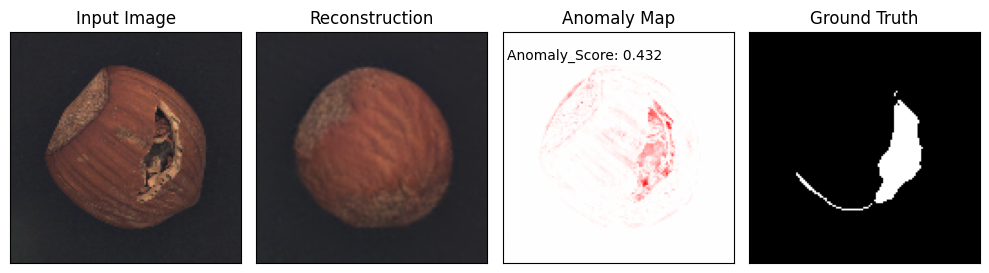

In [39]:
# PLOT IMAGES
fig,axs = plt.subplots(1,4, figsize=(10,4))
axs[0].imshow(I_A); axs[0].set_title('Input Image'); axs[0].set_xticks([]); axs[0].set_yticks([])
axs[1].imshow(R_A); axs[1].set_title('Reconstruction'); axs[1].set_xticks([]); axs[1].set_yticks([])
axs[2].imshow(diff_img, cmap='bwr', vmin=-am_max, vmax=am_max); axs[2].set_title('Anomaly Map'); axs[2].text(2,15,f'Anomaly_Score: {am_max:0.3}'); axs[2].set_xticks([]); axs[2].set_yticks([])
axs[3].imshow(ground_truth); axs[3].set_title('Ground Truth'); axs[3].set_xticks([]); axs[3].set_yticks([])
plt.tight_layout()
plt.show()

## XAI

In [40]:
import shap_bpt
# From "General Frameworks for Anomaly Detection Explainability: A comparative study"
## LOSS FUCNTIONS FOR SHAP
from keras import backend as K
def mean_predict(model, data):
    z_mean, _, _ = model.vae.encoder(data)
    reconstruction = model.vae.decoder(z_mean)
    return reconstruction
def lime_predict_loss(data):
    global model
    # batch_size = K.shape(data)[0]
    reconstruction = mean_predict(model, data)
    MSE_loss = tf.reduce_sum(tf.square(reconstruction - data), axis=[1,2,3])
    return np.array([ [l] for l in MSE_loss ])
def shap_bpt_masked_model(masks):
    X = []
    for m in masks:
        m3 = m
        img = R_A.copy()
        img[m3] = I_A[m3]
        X.append(img)
    return np.array(lime_predict_loss(np.array(X)))
#-----------------------------------------------------------------------------

In [17]:
bpt = shap_bpt.build_bpt_from_image((I_A*255).astype('uint8'))
explainer = shap_bpt.Explainer(shap_bpt_masked_model, I_A, num_explained_classes=1, verbose=True)

shap_values_AA = explainer.explain_instance(100,    method='AA',    batch_size=8,bpt=bpt)[0]
shap_values_BPT = explainer.explain_instance(100,   method='BPT',   batch_size=8,bpt=bpt)[0]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [43]:
# !pip install kaggle

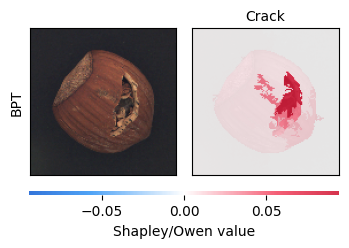

In [26]:
# shap_bpt.plot_owen_values(explainer, [shap_values_AA],['Crack'], names=['AxisAligned'])
# shap_bpt.plot_owen_values(explainer, [shap_values_BPT],['Crack'], names=['BPT'])
shap_bpt.plot_owen_values(explainer, [shap_values_BPT,shap_values_AA],['Crack'], names=['BPT','AxisAligned'])

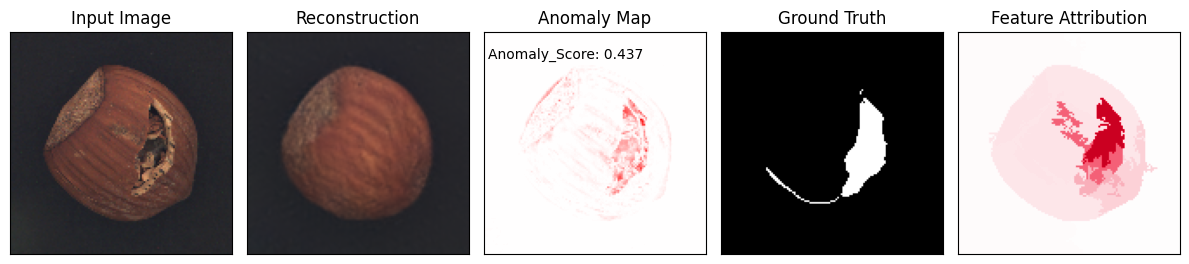

In [28]:
# PLOT IMAGES
fig,axs = plt.subplots(1,5, figsize=(12,6))
axs[0].imshow(I_A); axs[0].set_title('Input Image'); axs[0].set_xticks([]); axs[0].set_yticks([])
axs[1].imshow(R_A); axs[1].set_title('Reconstruction'); axs[1].set_xticks([]); axs[1].set_yticks([])
axs[2].imshow(diff_img, cmap='bwr', vmin=-am_max, vmax=am_max);  axs[2].text(2,15,f'Anomaly_Score: {am_max:0.3}'); axs[2].set_title('Anomaly Map'); axs[2].set_xticks([]); axs[2].set_yticks([])
axs[3].imshow(ground_truth); axs[3].set_title('Ground Truth'); axs[3].set_xticks([]); axs[3].set_yticks([])
vm = np.max(np.abs(shap_values_BPT)); axs[4].imshow(shap_values_BPT, vmin = -vm, vmax = vm, cmap=shap_bpt.shapley_values_colormap)
axs[4].set_title('Feature Attribution'); axs[4].set_xticks([]); axs[4].set_yticks([])
plt.tight_layout()
plt.show()

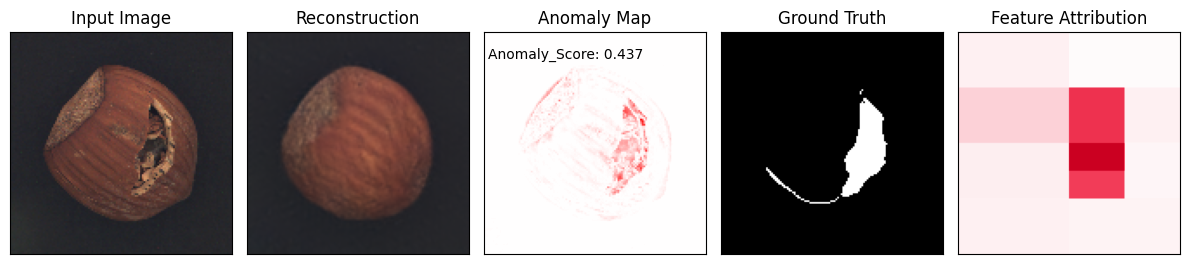

In [29]:
# PLOT IMAGES
fig,axs = plt.subplots(1,5, figsize=(12,6))
axs[0].imshow(I_A); axs[0].set_title('Input Image'); axs[0].set_xticks([]); axs[0].set_yticks([])
axs[1].imshow(R_A); axs[1].set_title('Reconstruction'); axs[1].set_xticks([]); axs[1].set_yticks([])
axs[2].imshow(diff_img, cmap='bwr', vmin=-am_max, vmax=am_max);  axs[2].text(2,15,f'Anomaly_Score: {am_max:0.3}'); axs[2].set_title('Anomaly Map'); axs[2].set_xticks([]); axs[2].set_yticks([])
axs[3].imshow(ground_truth); axs[3].set_title('Ground Truth'); axs[3].set_xticks([]); axs[3].set_yticks([])
vm = np.max(np.abs(shap_values_AA)); axs[4].imshow(shap_values_AA, vmin = -vm, vmax = vm, cmap=shap_bpt.shapley_values_colormap)
axs[4].set_title('Feature Attribution'); axs[4].set_xticks([]); axs[4].set_yticks([])
plt.tight_layout()
plt.show()